# Overfitting und Underfitting

> Warum ist ein Modell, das auf den Trainingsdaten perfekt funktioniert,  
> im echten Einsatz oft schlechter als ein einfacheres Modell?


## 0. Vorbereitung

Wir importieren alle benötigten Bibliotheken zu Beginn.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error

np.random.seed(42)
print("Imports erfolgreich geladen.")

Imports erfolgreich geladen.


## 1. Was sind Overfitting und Underfitting?

Beim maschinellen Lernen wollen wir Modelle, die **generalisieren** –  
also auf neuen, ungesehenen Daten gut funktionieren.

Dabei können zwei typische Fehler auftreten:

### Underfitting
Das Modell ist **zu einfach** und erfasst die eigentlichen Muster in den Daten nicht.  
Es macht sowohl auf Trainings- als auch auf Testdaten schlechte Vorhersagen.  
Ursache: zu geringe Modellkomplexität.

### Overfitting
Das Modell ist **zu komplex** und lernt nicht nur die echten Muster,  
sondern auch das zufällige Rauschen der Trainingsdaten auswendig.  
Es funktioniert auf Trainingsdaten sehr gut, auf Testdaten aber deutlich schlechter.  
Ursache: zu hohe Modellkomplexität oder zu wenig Trainingsdaten.

### Der gute Fit
Das Modell erfasst die relevanten Muster, ohne das Rauschen zu lernen.  
Train- und Test-Score liegen nah beieinander und auf einem guten Niveau.


### 1.0 Konzeptdiagramm: R² in Abhängigkeit von der Modellkomplexität

Bevor wir konkrete Modelle vergleichen, hilft dieses **konzeptuelle Diagramm**,  
das grundlegende Muster zu verstehen:

- Der **Train-Score** (blau) steigt mit zunehmender Komplexität monoton an –  
  ein komplexeres Modell kann die Trainingsdaten immer besser erklären.
- Der **Test-Score** (rot) steigt zunächst ebenfalls an, erreicht ein **Maximum**  
  (optimale Komplexität) und fällt dann wieder ab – das Modell überanpasst.

Die drei Bereiche sind deutlich erkennbar:  
`Underfitting` → `optimale Zone` → `Overfitting`

> **Hinweis für Lehrende:**  
> Dieser Plot ist eine stilisierte Illustration, keine Messung.  
> Er eignet sich ideal als Einstieg vor den empirischen Plots in Abschnitt 1.1 und 2.  
> Frage ins Plenum: *„An welchem Punkt würdet ihr das Modell stoppen?"*

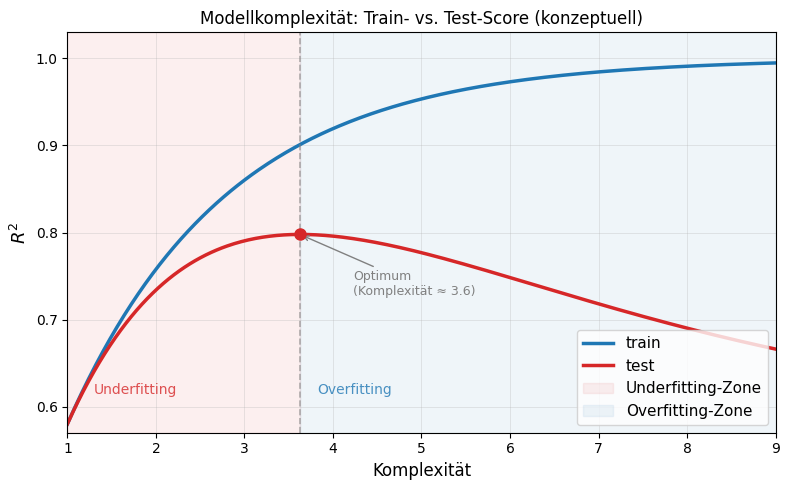

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Komplexitätsachse (stilisiert, nicht aus echten Daten)
x = np.linspace(1, 9, 400)

# Train-Kurve: steigt monoton gegen 1 (logarithmisch gesättigt)
train = 1 - 0.42 * np.exp(-0.55 * (x - 1))

# Test-Kurve: steigt, hat ein Maximum bei ~5, fällt dann ab
# Modelliert als Beta-ähnliche Kurve
test = 0.58 + 0.9 * (x - 1) / 4 * np.exp(-0.38 * (x - 1))

fig, ax = plt.subplots(figsize=(8, 5))

# Kurven
ax.plot(x, train, color="#1f77b4", linewidth=2.5, label="train")
ax.plot(x, test,  color="#d62728", linewidth=2.5, label="test")

# Optimum markieren
opt_idx = np.argmax(test)
opt_x   = x[opt_idx]
opt_y   = test[opt_idx]
ax.axvline(opt_x, color="gray", linewidth=1.2, linestyle="--", alpha=0.6)
ax.plot(opt_x, opt_y, "o", color="#d62728", markersize=8, zorder=5)
ax.annotate(f"Optimum\n(Komplexität \u2248 {opt_x:.1f})",
            xy=(opt_x, opt_y), xytext=(opt_x + 0.6, opt_y - 0.07),
            fontsize=9, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray", lw=1.0))

# Zonen einfärben
ax.axvspan(1,     opt_x, alpha=0.07, color="#d62728", label="Underfitting-Zone")
ax.axvspan(opt_x, 9,     alpha=0.07, color="#1f77b4", label="Overfitting-Zone")

# Zonenbezeichnungen
ax.text(1.3,          0.615, "Underfitting",  fontsize=10, color="#d62728", alpha=0.8)
ax.text(opt_x + 0.2,  0.615, "Overfitting",   fontsize=10, color="#1f77b4", alpha=0.8)

# Achsen & Beschriftung
ax.set_xlabel("Komplexität", fontsize=12)
ax.set_ylabel("$R^2$",        fontsize=13)
ax.set_title("Modellkomplexität: Train- vs. Test-Score (konzeptuell)",
             fontsize=12, fontweight="normal")
ax.set_xlim(1, 9)
ax.set_ylim(0.57, 1.03)
ax.set_xticks(range(1, 10))
ax.legend(fontsize=11, loc="lower right")
ax.grid(True, linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

### 1.1 Visualisierung: Die drei Fälle im Vergleich

Das folgende Beispiel zeigt polynomiale Regression auf synthetischen Daten.  
Die **wahre Funktion** ist ein Polynom 3. Grades mit Rauschen.  
Wir passen drei Modelle an – mit Grad 1, 3 und 15 – und sehen sofort den Unterschied.

In [ ]:
# ── Datensatz A: Fit-Plots (klein, damit Overfitting bei Grad 15 sichtbar) ────
n_samples = 50
X_raw = np.sort(np.random.uniform(-3, 3, n_samples))
y_raw = 0.5 * X_raw**3 - X_raw**2 + 2 + np.random.normal(0, 2.5, n_samples)

X_plot = np.linspace(-3.2, 3.2, 300).reshape(-1, 1)
X_fit  = X_raw.reshape(-1, 1)


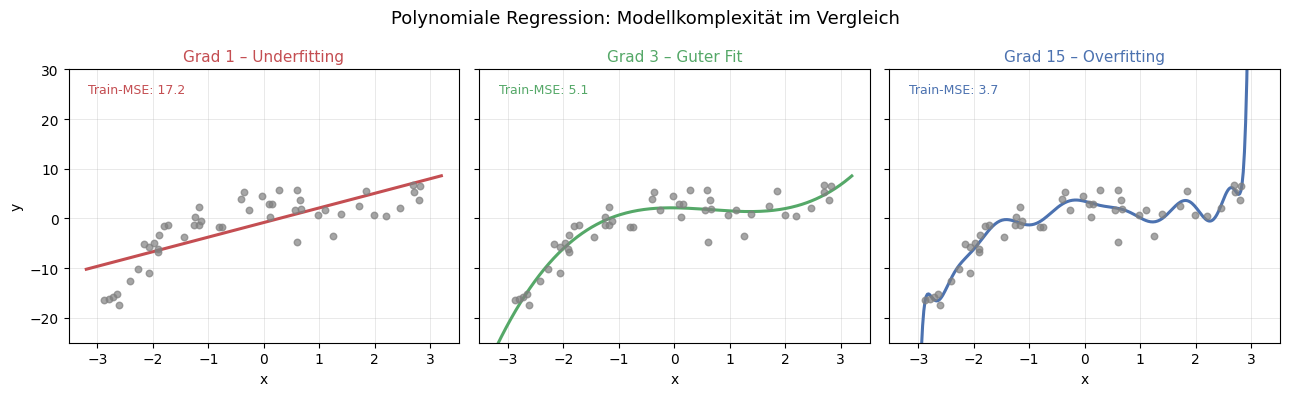

In [ ]:
degrees = [1, 3, 15]
titles  = ["Grad 1 – Underfitting", "Grad 3 – Guter Fit", "Grad 15 – Overfitting"]
colors  = ["#C44E52", "#55A868", "#4C72B0"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle("Polynomiale Regression: Modellkomplexität im Vergleich",
             fontsize=13, fontweight="normal")

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X_fit, y_raw)
    y_curve = model.predict(X_plot)

    train_mse = mean_squared_error(y_raw, model.predict(X_fit))

    ax.scatter(X_raw, y_raw, color="gray", s=22, alpha=0.7,
               zorder=3, label="Datenpunkte")
    ax.plot(X_plot, y_curve, color=color, linewidth=2.2,
            label=f"Polynom Grad {deg}")
    ax.set_title(title, fontsize=11, color=color)
    ax.set_xlabel("x")
    ax.set_ylim(-25, 30)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.text(0.05, 0.95, f"Train-MSE: {train_mse:.1f}",
            transform=ax.transAxes, fontsize=9,
            verticalalignment="top", color=color)

axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()